In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('df_pca.csv')

In [2]:
pre      = df[df['Stage'] == 'Stage 1 (2017-2019)']
pandemic = df[df['Stage'] == 'Stage 2 (2020-2022)']
post     = df[df['Stage'] == 'Stage 3 (2023-2025)']
print(f'Pre:      {len(pre):,} rows')
print(f'Pandemic: {len(pandemic):,} rows')
print(f'Post:     {len(post):,} rows')

Pre:      31,217 rows
Pandemic: 31,425 rows
Post:     29,067 rows


In [3]:
pcs = ['PC1', 'PC2', 'PC3', 'PC4']
pc_labels = {
    'PC1': 'PC1 Intensity',
    'PC2': 'PC2 Vocal Style',
    'PC3': 'PC3 Instrumentalness',
    'PC4': 'PC4 Positive Vocal'
}

means = pd.DataFrame({
    'Pre (2017–2019)':      pre[pcs].mean(),
    'Pandemic (2020–2022)': pandemic[pcs].mean(),
    'Post (2023–2025)':     post[pcs].mean()
}).round(4)

print("The avarage of each stage's pcs")
print(means.to_string())

The avarage of each stage's pcs
     Pre (2017–2019)  Pandemic (2020–2022)  Post (2023–2025)
PC1           0.1752                0.0150           -0.2044
PC2           0.1725                0.0844           -0.2765
PC3           0.0456               -0.0647            0.0210
PC4          -0.1529               -0.0069            0.1717


In [4]:
print('Normality test (Shapiro-Wilk, sample size 5000)')
for pc in pcs:
    sample = pre[pc].sample(5000, random_state=42)
    stat, p = stats.shapiro(sample)
    print(f'Pre  {pc}: W={stat:.4f}, p={p:.4f} → {"Normal" if p>0.05 else "Non-normal"}')

print()
print('Note: The sample size is extremely large (> 30,000), and the t-test remains robust even in large samples.')
print('This analysis also reports both the t-test and the Mann-Whitney test. If the results of both tests are consistent, the conclusion is more reliable.')

Normality test (Shapiro-Wilk, sample size 5000)
Pre  PC1: W=0.9337, p=0.0000 → Non-normal
Pre  PC2: W=0.9584, p=0.0000 → Non-normal
Pre  PC3: W=0.8542, p=0.0000 → Non-normal
Pre  PC4: W=0.9677, p=0.0000 → Non-normal

Note: The sample size is extremely large (> 30,000), and the t-test remains robust even in large samples.
This analysis also reports both the t-test and the Mann-Whitney test. If the results of both tests are consistent, the conclusion is more reliable.


In [5]:
def cohens_d(a, b):
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / pooled_std

def effect_label(d):
    """The interpretation of cohens"""
    d = abs(d)
    if d < 0.2:   return 'negligible'
    elif d < 0.5: return 'small'
    elif d < 0.8: return 'medium'
    else:         return 'large'

comparisons = [
    ('Pre',      'Pandemic', pre, pandemic),
    ('Pandemic', 'Post',     pandemic, post),
    ('Pre',      'Post',     pre, post),
]

results = []
for name1, name2, g1, g2 in comparisons:
    for pc in pcs:
        a, b = g1[pc].dropna(), g2[pc].dropna()
        
        # Welch t-test（do not assume equal variances）
        t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
        
        # Mann-Whitney U（Non-parametric）
        u_stat, u_p = stats.mannwhitneyu(a, b, alternative='two-sided')
        
        # Cohen's d
        d = cohens_d(a, b)
        
        results.append({
            'Comparison':   f'{name1} vs {name2}',
            'PC':           pc,
            'Mean_A':       round(a.mean(), 4),
            'Mean_B':       round(b.mean(), 4),
            'Δ Mean':       round(a.mean() - b.mean(), 4),
            't_stat':       round(t_stat, 4),
            't_p':          round(t_p, 6),
            't_sig':        '***' if t_p < 0.001 else ('**' if t_p < 0.01 else ('*' if t_p < 0.05 else 'ns')),
            'MW_p':         round(u_p, 6),
            'MW_sig':       '***' if u_p < 0.001 else ('**' if u_p < 0.01 else ('*' if u_p < 0.05 else 'ns')),
            "Cohen's d":    round(d, 4),
            'Effect Size':  effect_label(d)
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

      Comparison  PC  Mean_A  Mean_B  Δ Mean   t_stat      t_p t_sig     MW_p MW_sig  Cohen's d Effect Size
 Pre vs Pandemic PC1  0.1752  0.0150  0.1602  13.6644 0.000000   *** 0.000000    ***     0.1092  negligible
 Pre vs Pandemic PC2  0.1725  0.0844  0.0880   9.9776 0.000000   *** 0.000000    ***     0.0797  negligible
 Pre vs Pandemic PC3  0.0456 -0.0647  0.1102  16.1536 0.000000   *** 0.000000    ***     0.1290  negligible
 Pre vs Pandemic PC4 -0.1529 -0.0069 -0.1460 -19.9426 0.000000   *** 0.000000    ***    -0.1594  negligible
Pandemic vs Post PC1  0.0150 -0.2044  0.2194  15.6824 0.000000   *** 0.000000    ***     0.1280  negligible
Pandemic vs Post PC2  0.0844 -0.2765  0.3609  42.8696 0.000000   *** 0.000000    ***     0.3483       small
Pandemic vs Post PC3 -0.0647  0.0210 -0.0856  -9.4669 0.000000   *** 0.161483     ns    -0.0775  negligible
Pandemic vs Post PC4 -0.0069  0.1717 -0.1786 -22.4621 0.000000   *** 0.000000    ***    -0.1832  negligible
     Pre vs Post PC1  0.1752

In [6]:
results_df.to_csv('A_ttest_results.csv', index=False)
print()

print('=== Significance Summary（*** p<0.001, ** p<0.01, * p<0.05, ns 不显著）===')
summary = results_df[['Comparison', 'PC', 'Δ Mean', 't_sig', "Cohen's d", 'Effect Size']]
print(summary.to_string(index=False))


=== Significance Summary（*** p<0.001, ** p<0.01, * p<0.05, ns 不显著）===
      Comparison  PC  Δ Mean t_sig  Cohen's d Effect Size
 Pre vs Pandemic PC1  0.1602   ***     0.1092  negligible
 Pre vs Pandemic PC2  0.0880   ***     0.0797  negligible
 Pre vs Pandemic PC3  0.1102   ***     0.1290  negligible
 Pre vs Pandemic PC4 -0.1460   ***    -0.1594  negligible
Pandemic vs Post PC1  0.2194   ***     0.1280  negligible
Pandemic vs Post PC2  0.3609   ***     0.3483       small
Pandemic vs Post PC3 -0.0856   ***    -0.0775  negligible
Pandemic vs Post PC4 -0.1786   ***    -0.1832  negligible
     Pre vs Post PC1  0.3796   ***     0.2344       small
     Pre vs Post PC2  0.4489   ***     0.4222       small
     Pre vs Post PC3  0.0246    **     0.0235  negligible
     Pre vs Post PC4 -0.3247   ***    -0.3354       small


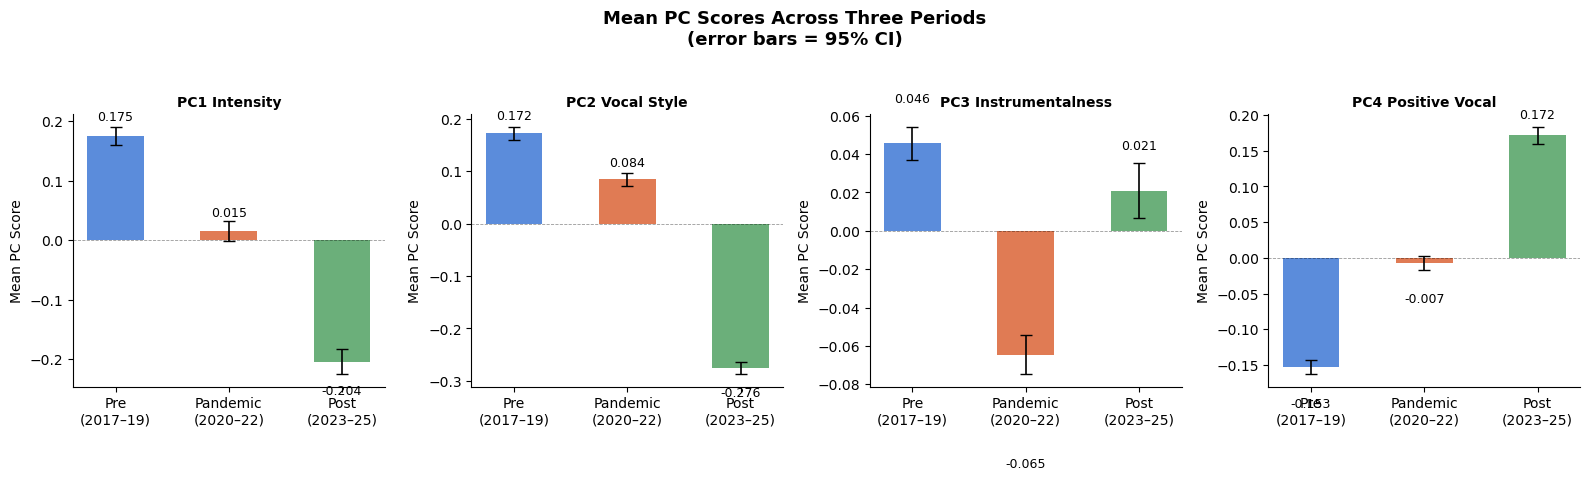

saved to pc_means_barplot.png


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ['#5B8CDB', '#E07B54', '#6BAF7A']
stages = ['Pre\n(2017–19)', 'Pandemic\n(2020–22)', 'Post\n(2023–25)']
groups = [pre, pandemic, post]

for i, pc in enumerate(pcs):
    ax = axes[i]
    vals = [g[pc].mean() for g in groups]
    errs = [g[pc].sem() * 1.96 for g in groups]  # 95% CI
    
    bars = ax.bar(stages, vals, color=colors, width=0.5,
                  yerr=errs, capsize=4, error_kw={'linewidth': 1.2})
    
    # 标注数值
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.02 if val >= 0 else -0.06),
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.4)
    ax.set_title(pc_labels[pc], fontsize=10, fontweight='bold')
    ax.set_ylabel('Mean PC Score')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Mean PC Scores Across Three Periods\n(error bars = 95% CI)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pc_means_barplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved to pc_means_barplot.png')

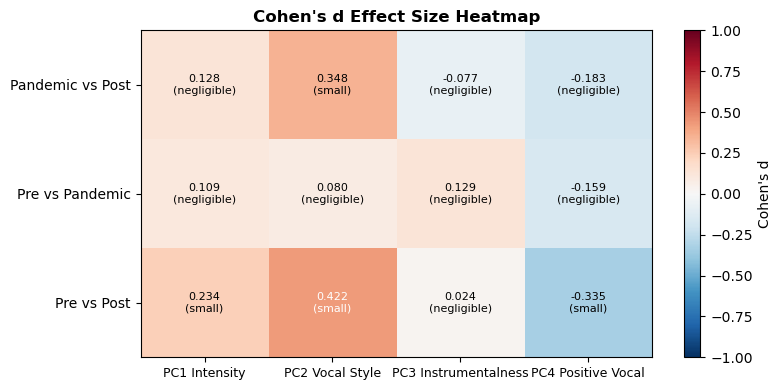

saved to cohens_d_heatmap.png


In [10]:
import matplotlib.colors as mcolors

pivot = results_df.pivot(index='Comparison', columns='PC', values="Cohen's d")

fig, ax = plt.subplots(figsize=(8, 4))
cmap = plt.cm.RdBu_r
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

im = ax.imshow(pivot.values, cmap=cmap, norm=norm, aspect='auto')
plt.colorbar(im, ax=ax, label="Cohen's d")

ax.set_xticks(range(len(pcs)))
ax.set_xticklabels([pc_labels[p] for p in pcs], fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)

for i in range(len(pivot.index)):
    for j, pc in enumerate(pcs):
        d_val = pivot.values[i, j]
        label = effect_label(d_val)
        ax.text(j, i, f'{d_val:.3f}\n({label})',
                ha='center', va='center', fontsize=8,
                color='white' if abs(d_val) > 0.4 else 'black')

ax.set_title("Cohen's d Effect Size Heatmap", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cohens_d_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved to cohens_d_heatmap.png')

In [13]:
pre_vs_pandemic = results_df[results_df['Comparison'] == 'Pre vs Pandemic']

print('=== H1 conclusion ===')
print()
sig_pcs = pre_vs_pandemic[pre_vs_pandemic['t_sig'] != 'ns']['PC'].tolist()
ns_pcs  = pre_vs_pandemic[pre_vs_pandemic['t_sig'] == 'ns']['PC'].tolist()

if len(sig_pcs) >= 3:
    print(f'H1 support：There are significant differences on {sig_pcs} between Pre and Pandemic')
else:
    print(f'H1 partially support：Only {sig_pcs} is significant, while {ns_pcs} is not significant.')

print()
for _, row in pre_vs_pandemic.iterrows():
    direction = '↓ decrease' if row['Δ Mean'] > 0 else '↑ ascend'
    cd = row["Cohen's d"]
    ef = row['Effect Size']
    pc = row['PC']
    delta = row['Δ Mean']
    sig = row['t_sig']
    label = pc_labels[pc]
    print(f"{pc} ({label}): Δ={delta:+.4f} {direction}, Cohen's d={cd:.4f} ({ef}), p{sig}")

=== H1 conclusion ===

H1 support：There are significant differences on ['PC1', 'PC2', 'PC3', 'PC4'] between Pre and Pandemic

PC1 (PC1 Intensity): Δ=+0.1602 ↓ decrease, Cohen's d=0.1092 (negligible), p***
PC2 (PC2 Vocal Style): Δ=+0.0880 ↓ decrease, Cohen's d=0.0797 (negligible), p***
PC3 (PC3 Instrumentalness): Δ=+0.1102 ↓ decrease, Cohen's d=0.1290 (negligible), p***
PC4 (PC4 Positive Vocal): Δ=-0.1460 ↑ ascend, Cohen's d=-0.1594 (negligible), p***
